# Chest X-ray adversarial training — PyTorch version

This notebook is the PyTorch conversion of the TensorFlow/Keras adversarial training notebook.

It is designed to run **after** `cnn_pytorch_converted.ipynb` and uses the saved model:

- `baseline_resnet152.pth`

Main steps:
1. Rebuild the PyTorch ResNet152 binary classifier
2. Load the saved `.pth` weights
3. Evaluate clean accuracy on `chest_xray/test`, `Master_Dataset/test`, and `Kermany_Pediatric_Attack`
4. Evaluate FGSM robustness
5. Run adversarial training on `chest_xray/train`
6. Optionally fine-tune on `Master_Dataset/train`
7. Save the resulting models as `.pth`


In [34]:

import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score


In [35]:

IMG_SIZE = 224
BATCH = 16
SEED = 42
EPSILON = 0.01

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)


Using device: cuda


## Model definition and loading

In [36]:
import torch
import torch.nn as nn
import torchvision.models as models

class BaselineResNet152(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.resnet152(weights=None)

        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.model(x)

def load_baseline_model(weights_path):
    model = BaselineResNet152().to(device)
    state = torch.load(weights_path, map_location=device)

    first_key = next(iter(state.keys()))

    if first_key.startswith("model."):
        model.load_state_dict(state, strict=True)
    else:
        model.model.load_state_dict(state, strict=True)

    model.eval()
    return model

## Transforms

In [37]:

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])


## FGSM and evaluation helpers

In [38]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

criterion = nn.BCEWithLogitsLoss()

imagenet_mean_t = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
imagenet_std_t = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

def clamp_normalized(x):
    x_min = (0.0 - imagenet_mean_t) / imagenet_std_t
    x_max = (1.0 - imagenet_mean_t) / imagenet_std_t
    return torch.clamp(x, min=x_min, max=x_max)

def get_logits(model, x):
    logits = model(x)
    if isinstance(logits, tuple):
        logits = logits[0]
    return logits.view(-1, 1)

def fgsm_attack(model, images, labels, epsilon=0.01):
    was_training = model.training
    model.eval()

    images = images.detach().clone().to(device)
    labels = labels.detach().clone().to(device).float().view(-1, 1)
    images.requires_grad_(True)

    logits = get_logits(model, images)
    loss = criterion(logits, labels)

    model.zero_grad(set_to_none=True)
    loss.backward()

    adv_images = images + epsilon * images.grad.sign()
    adv_images = clamp_normalized(adv_images).detach()

    if was_training:
        model.train()

    return adv_images

def evaluate_clean(model, loader):
    model.eval()
    running_loss = 0.0
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device).float().view(-1, 1)

            logits = get_logits(model, images)
            loss = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()

            all_labels.extend(labels.cpu().numpy().ravel().astype(int))
            all_preds.extend(preds.cpu().numpy().ravel().astype(int))
            all_probs.extend(probs.cpu().numpy().ravel())

    loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)

    return loss, acc, f1, auc

def evaluate_fgsm(model, loader, epsilon=0.01):
    model.eval()
    running_loss = 0.0
    all_labels, all_preds, all_probs = [], [], []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).float().view(-1, 1)

        adv_images = fgsm_attack(model, images, labels, epsilon=epsilon)

        with torch.no_grad():
            logits = get_logits(model, adv_images)
            loss = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()

        all_labels.extend(labels.cpu().numpy().ravel().astype(int))
        all_preds.extend(preds.cpu().numpy().ravel().astype(int))
        all_probs.extend(probs.cpu().numpy().ravel())

    loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)

    return loss, acc, f1, auc

## Evaluation datasets

In [39]:

ds_clean = datasets.ImageFolder(root="chest_xray/test", transform=eval_transform)
loader_clean = DataLoader(ds_clean, batch_size=BATCH, shuffle=False, num_workers=0)

print("Clean classes:", ds_clean.class_to_idx)

ds_master = datasets.ImageFolder(root="Master_Dataset/test", transform=eval_transform)
loader_master = DataLoader(ds_master, batch_size=BATCH, shuffle=False, num_workers=0)

print("Master classes:", ds_master.class_to_idx)

ds_kermany = datasets.ImageFolder(root="Kermany_Pediatric_Attack", transform=eval_transform)
loader_kermany = DataLoader(ds_kermany, batch_size=BATCH, shuffle=False, num_workers=0)

print("Kermany classes:", ds_kermany.class_to_idx)


Clean classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Master classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Kermany classes: {'NORMAL': 0, 'PNEUMONIA': 1}


## Clean evaluation on baseline model

In [ ]:
model = load_baseline_model("baseline_resnet152.pth")
model = model.to(device)

clean_loss, clean_acc, clean_f1, clean_auc = evaluate_clean(model, loader_clean)
master_loss, master_acc, master_f1, master_auc = evaluate_clean(model, loader_master)
kermany_loss, kermany_acc, kermany_f1, kermany_auc = evaluate_clean(model, loader_kermany)

print("Clean (chest_xray)")
print(f"  Loss    : {clean_loss:.4f}")
print(f"  Accuracy: {clean_acc:.4f}")
print(f"  F1      : {clean_f1:.4f}")
print(f"  ROC-AUC : {clean_auc:.4f}")
print()

print("Clean (master)")
print(f"  Loss    : {master_loss:.4f}")
print(f"  Accuracy: {master_acc:.4f}")
print(f"  F1      : {master_f1:.4f}")
print(f"  ROC-AUC : {master_auc:.4f}")
print()

print("Clean (kermany)")
print(f"  Loss    : {kermany_loss:.4f}")
print(f"  Accuracy: {kermany_acc:.4f}")
print(f"  F1      : {kermany_f1:.4f}")
print(f"  ROC-AUC : {kermany_auc:.4f}")

C:\Users\thoai\AppData\Local\Temp\ipykernel_40688\2558813194.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(weights_path, map_location=device)


Clean (chest_xray): 0.9777887354810433
Clean (master): 0.6824668745027613
Clean (kermany): 0.9391847468770547


## FGSM evaluation on baseline model

In [42]:

eps = EPSILON

_, _, _, fgsm_clean_acc = evaluate_fgsm(model, loader_clean, epsilon=eps)
_, _, _, fgsm_master_acc = evaluate_fgsm(model, loader_master, epsilon=eps)
_, _, _, fgsm_kermany_acc = evaluate_fgsm(model, loader_kermany, epsilon=eps)

print("FGSM acc (chest_xray):", fgsm_clean_acc)
print("FGSM acc (master):", fgsm_master_acc)
print("FGSM acc (kermany):", fgsm_kermany_acc)


FGSM acc (chest_xray): 0.842603550295858
FGSM acc (master): 0.6674110671424609
FGSM acc (kermany): 0.8064321718167873


## Adversarial training helpers

In [ ]:

def adversarial_train_step(model, optimizer, images, labels, epsilon=0.01):
    images = images.to(device)
    labels = labels.to(device).float().unsqueeze(1)

    adv_images = fgsm_attack(model, images, labels.squeeze(1), epsilon=epsilon)

    combined_images = torch.cat([images, adv_images], dim=0)
    combined_labels = torch.cat([labels, labels], dim=0)

    model.train()
    optimizer.zero_grad(set_to_none=True)

    logits = model(combined_images)
    loss = criterion(logits, combined_labels)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        acc = (preds.eq(combined_labels).float().mean()).item()

    return loss.item(), acc

def adversarial_train(model, train_loader, val_loader, epochs=5, epsilon=0.01, lr=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_clean_acc": [],
        "val_fgsm_acc": [],
    }

    for epoch in range(epochs):
        model.train()
        epoch_losses = []
        epoch_accs = []

        for images, labels in train_loader:
            loss, acc = adversarial_train_step(model, optimizer, images, labels, epsilon=epsilon)
            epoch_losses.append(loss)
            epoch_accs.append(acc)

        train_loss = float(np.mean(epoch_losses))
        train_acc = float(np.mean(epoch_accs))
        _, _, _, val_clean_acc = evaluate_clean(model, val_loader)
        _, _, _, val_fgsm_acc = evaluate_fgsm(model, val_loader, epsilon=epsilon)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_clean_acc"].append(val_clean_acc)
        history["val_fgsm_acc"].append(val_fgsm_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Loss: {train_loss:.4f} | "
            f"Adv-train acc: {train_acc*100:.2f}% | "
            f"Val clean acc: {val_clean_acc*100:.2f}% | "
            f"Val FGSM acc: {val_fgsm_acc*100:.2f}%"
        )

    return model, history


## Adversarial training on combined `chest_xray/train` + `Master_Dataset/train`

This is now the recommended main path. Instead of adversarial-training on `chest_xray/train` and then clean fine-tuning on `Master_Dataset/train`, we first combine the clean training distributions and adversarial-train on the merged data.

In [ ]:
from torch.utils.data import ConcatDataset, Subset

def make_train_val_subsets(root, train_transform, eval_transform, val_ratio=0.2, seed=42):
    ds_train_view = datasets.ImageFolder(root=root, transform=train_transform)
    ds_eval_view = datasets.ImageFolder(root=root, transform=eval_transform)

    n = len(ds_train_view)
    indices = torch.randperm(n, generator=torch.Generator().manual_seed(seed)).tolist()
    val_size = max(1, int(val_ratio * n))
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]

    return Subset(ds_train_view, train_indices), Subset(ds_eval_view, val_indices)

train_parts = []
val_parts = []

if os.path.exists("chest_xray/train"):
    tr, va = make_train_val_subsets("chest_xray/train", train_transform, eval_transform, val_ratio=0.2, seed=SEED)
    train_parts.append(tr)
    val_parts.append(va)

if os.path.exists("Master_Dataset/train"):
    tr, va = make_train_val_subsets("Master_Dataset/train", train_transform, eval_transform, val_ratio=0.2, seed=SEED)
    train_parts.append(tr)
    val_parts.append(va)

if len(train_parts) == 0:
    raise FileNotFoundError("No training datasets found. Expected 'chest_xray/train' and/or 'Master_Dataset/train'.")

combined_train_ds = ConcatDataset(train_parts)
combined_val_ds = ConcatDataset(val_parts)

train_loader = DataLoader(combined_train_ds, batch_size=BATCH, shuffle=True, num_workers=0)
val_loader = DataLoader(combined_val_ds, batch_size=BATCH, shuffle=False, num_workers=0)

print("Combined train samples:", len(combined_train_ds))
print("Combined val samples:", len(combined_val_ds))

Combined train samples: 15430
Combined val samples: 3856


In [ ]:
for param in model.model.parameters():
    param.requires_grad = False

for param in model.model.layer4.parameters():
    param.requires_grad = True

for param in model.model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [ ]:
model = load_baseline_model("baseline_resnet152.pth")

model, history_adv = adversarial_train(
    model,
    train_loader,
    val_loader,
    epochs=8,
    epsilon=EPSILON,
    lr=1e-4,
)



C:\Users\thoai\AppData\Local\Temp\ipykernel_32948\98270459.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(weights_path, map_location=map_location)


KeyboardInterrupt: 

In [ ]:
# torch.save(model_adv.state_dict(), "baseline_resnet152_adversarial_combined.pth")
# print("Saved to baseline_resnet152_adversarial_combined.pth")

Saved to baseline_resnet152_adversarial_combined.pth


## Evaluate adversarially trained combined-data model

In [58]:
model = load_baseline_model("baseline_resnet152_adversarial_combined.pth")

clean_loss, clean_acc, clean_f1, clean_auc = evaluate_clean(model, loader_clean)
master_loss, master_acc, master_f1, master_auc = evaluate_clean(model, loader_master)
kermany_loss, kermany_acc, kermany_f1, kermany_auc = evaluate_clean(model, loader_kermany)

print("Clean (chest_xray)")
print(f"  Loss    : {clean_loss:.4f}")
print(f"  Accuracy: {clean_acc:.4f}")
print(f"  F1      : {clean_f1:.4f}")
print(f"  ROC-AUC : {clean_auc:.4f}")
print()

print("Clean (master)")
print(f"  Loss    : {master_loss:.4f}")
print(f"  Accuracy: {master_acc:.4f}")
print(f"  F1      : {master_f1:.4f}")
print(f"  ROC-AUC : {master_auc:.4f}")
print()

print("Clean (kermany)")
print(f"  Loss    : {kermany_loss:.4f}")
print(f"  Accuracy: {kermany_acc:.4f}")
print(f"  F1      : {kermany_f1:.4f}")
print(f"  ROC-AUC : {kermany_auc:.4f}")

C:\Users\thoai\AppData\Local\Temp\ipykernel_40688\2558813194.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(weights_path, map_location=device)


Clean (chest_xray)
  Loss    : 0.1835
  Accuracy: 0.9487
  F1      : 0.9599
  ROC-AUC : 0.9937

Clean (master)
  Loss    : 1.0334
  Accuracy: 0.7775
  F1      : 0.7754
  ROC-AUC : 0.8643

Clean (kermany)
  Loss    : 0.4949
  Accuracy: 0.8889
  F1      : 0.8984
  ROC-AUC : 0.9829


In [ ]:
eps = EPSILON

fgsm_clean_loss, fgsm_clean_acc, fgsm_clean_f1, fgsm_clean_auc = evaluate_fgsm(model, loader_clean, epsilon=eps)
fgsm_master_loss, fgsm_master_acc, fgsm_master_f1, fgsm_master_auc = evaluate_fgsm(model, loader_master, epsilon=eps)
fgsm_kermany_loss, fgsm_kermany_acc, fgsm_kermany_f1, fgsm_kermany_auc = evaluate_fgsm(model, loader_kermany, epsilon=eps)

print(f"FGSM (epsilon={eps}) (chest_xray)")
print(f"  Loss    : {fgsm_clean_loss:.4f}")
print(f"  Accuracy: {fgsm_clean_acc:.4f}")
print(f"  F1      : {fgsm_clean_f1:.4f}")
print(f"  ROC-AUC : {fgsm_clean_auc:.4f}")
print()

print(f"FGSM (epsilon={eps}) (master)")
print(f"  Loss    : {fgsm_master_loss:.4f}")
print(f"  Accuracy: {fgsm_master_acc:.4f}")
print(f"  F1      : {fgsm_master_f1:.4f}")
print(f"  ROC-AUC : {fgsm_master_auc:.4f}")
print()

print(f"FGSM (epsilon={eps}) (kermany)")
print(f"  Loss    : {fgsm_kermany_loss:.4f}")
print(f"  Accuracy: {fgsm_kermany_acc:.4f}")
print(f"  F1      : {fgsm_kermany_f1:.4f}")
print(f"  ROC-AUC : {fgsm_kermany_auc:.4f}")

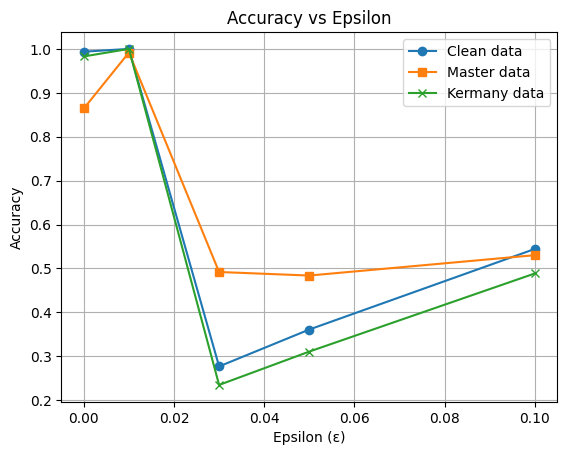

In [57]:
epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]
all_fgsm_clean_acc = []
all_fgsm_master_acc = []
all_fgsm_kermany_acc = []
for eps in epsilons:
    _, _, _, fgsm_clean_acc = evaluate_fgsm(model, loader_clean, epsilon=eps)
    _, _, _, fgsm_master_acc = evaluate_fgsm(model, loader_master, epsilon=eps)
    _, _, _, fgsm_kermany_acc = evaluate_fgsm(model, loader_kermany, epsilon=eps)

    all_fgsm_clean_acc.append(fgsm_clean_acc)
    all_fgsm_master_acc.append(fgsm_master_acc)
    all_fgsm_kermany_acc.append(fgsm_kermany_acc)

import matplotlib.pyplot as plt

# Plot both curves
plt.plot(epsilons, all_fgsm_clean_acc, marker='o', label='Clean data')
plt.plot(epsilons, all_fgsm_master_acc, marker='s', label='Master data')
plt.plot(epsilons, all_fgsm_kermany_acc, marker='x', label='Kermany data')

# Labels and title
plt.xlabel('Epsilon (ε)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epsilon')

# Legend
plt.legend()

# Show
plt.grid(True)
plt.show()

COMBINED METRICS

In [48]:
labels_clean, preds_clean, probs_clean, clean_acc = evaluate_clean(model_adv, loader_clean)
labels_master, preds_master, probs_master, master_acc = evaluate_clean(model_adv, loader_master)
labels_kermany, preds_kermany, probs_kermany, kermany_acc = evaluate_clean(model_adv, loader_kermany)

labels_clean_fgsm, preds_clean_fgsm, probs_clean_fgsm, clean_fgsm_acc = evaluate_fgsm(
    model_adv, loader_clean, epsilon=0.01
)
labels_master_fgsm, preds_master_fgsm, probs_master_fgsm, master_fgsm_acc = evaluate_fgsm(
    model_adv, loader_master, epsilon=0.01
)
labels_kermany_fgsm, preds_kermany_fgsm, probs_kermany_fgsm, kermany_fgsm_acc = evaluate_fgsm(
    model_adv, loader_kermany, epsilon=0.01
)

print("Combined adversarial model clean (chest_xray):", clean_acc)
print("Combined adversarial model clean (master):", master_acc)
print("Combined adversarial model clean (kermany):", kermany_acc)
print("Combined adversarial model FGSM (chest_xray):", clean_fgsm_acc)
print("Combined adversarial model FGSM (master):", master_fgsm_acc)
print("Combined adversarial model FGSM (kermany):", kermany_fgsm_acc)

Combined adversarial model clean (chest_xray): 0.9777887354810433
Combined adversarial model clean (master): 0.6824668745027613
Combined adversarial model clean (kermany): 0.9391847468770547
Combined adversarial model FGSM (chest_xray): 0.842603550295858
Combined adversarial model FGSM (master): 0.6674110671424609
Combined adversarial model FGSM (kermany): 0.8064321718167873


## Note on the old `Master_Dataset/train` clean fine-tune path

That old path is left out on purpose here. Clean fine-tuning on Master *after* adversarial training can partially wash out robustness, so the combined-data adversarial path above is the preferred final pipeline.

In [ ]:
print("Skipped: old clean Master fine-tune stage removed. Preferred path = combined clean data -> adversarial training.")

Skipped: old clean Master fine-tune stage removed. Preferred path = combined clean data -> adversarial training.


## Final evaluation block

In [49]:
final_model_path = "baseline_resnet152_adversarial_combined.pth"
if os.path.exists(final_model_path):
    model_final = load_baseline_model(final_model_path)

    labels_clean, preds_clean, _, clean_acc = evaluate_clean(model_final, loader_clean)
    labels_master, preds_master, _, master_acc = evaluate_clean(model_final, loader_master)
    labels_kermany, preds_kermany, _, kermany_acc = evaluate_clean(model_final, loader_kermany)

    print("Final clean (chest_xray):", clean_acc)
    print("Final clean (master):", master_acc)
    print("Final clean (kermany):", kermany_acc)

    _, _, _, fgsm_clean_acc = evaluate_fgsm(model_final, loader_clean, epsilon=EPSILON)
    _, _, _, fgsm_master_acc = evaluate_fgsm(model_final, loader_master, epsilon=EPSILON)
    _, _, _, fgsm_kermany_acc = evaluate_fgsm(model_final, loader_kermany, epsilon=EPSILON)

    print("Final FGSM (chest_xray):", fgsm_clean_acc)
    print("Final FGSM (master):", fgsm_master_acc)
    print("Final FGSM (kermany):", fgsm_kermany_acc)
else:
    print("Final model not found. Run the combined adversarial training cells first, or change final_model_path.")

C:\Users\thoai\AppData\Local\Temp\ipykernel_40688\2558813194.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(weights_path, map_location=device)


Final clean (chest_xray): 0.9936993206223976
Final clean (master): 0.8643137392097564
Final clean (kermany): 0.9829151143253707
Final FGSM (chest_xray): 1.0
Final FGSM (master): 0.9918174255793883
Final FGSM (kermany): 1.0


## Dataset combination summary

The notebook now treats the merged `chest_xray/train` + `Master_Dataset/train` path as the main adversarial-training route.

In [ ]:
combined_train_roots = []
if os.path.exists("chest_xray/train"):
    combined_train_roots.append("chest_xray/train")
if os.path.exists("Master_Dataset/train"):
    combined_train_roots.append("Master_Dataset/train")

print("Training roots used for combined adversarial training:")
for root in combined_train_roots:
    print("-", root)